<a href="https://colab.research.google.com/github/CynthiaChaaya/product-adoption-rates-and-market-trends-predictions-using-sentiment-analysis/blob/main/product-adoption-rates-and-market-trends-predictions-using-sentiment-analysis%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Reviews Analysis to Predict Product Adoption Rates and Market Trends

Cynthia Chaaya

### Installing and Importing All Necessary Extensions

In [ ]:
!pip install tensorflow transformers datasets scikit-learn pandas tqdm

In [ ]:
import pandas as pd
import numpy as np
from transformers import BertTokenizer, TFBertModel, pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve, f1_score, confusion_matrix, roc_auc_score, precision_score, recall_score
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm
import tensorflow as tf
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization
from transformers import TFBertModel, BertTokenizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### Preprocessing the Dataset

In [ ]:
df = pd.read_csv("Womens_Clothing_Reviews_with_Dates.csv", on_bad_lines='skip')
df = df.dropna(subset=["Review Text"])

In [ ]:
sentiment_analyzer = pipeline("sentiment-analysis")
df['Sentiment'] = df['Review Text'].astype(str).apply(
    lambda x: sentiment_analyzer(x)[0]['label']
)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
df['Sentiment'] = df['Sentiment'].map({'POSITIVE': 1, 'NEGATIVE': 0})

In [ ]:
texts = df["Review Text"].astype(str).tolist()

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [ ]:
encodings = tokenizer(texts, truncation=True, padding=True, max_length=128, return_tensors="tf")

In [ ]:
print(df[['Review Text', 'Sentiment']].head(10))

                                         Review Text  Sentiment
0  Absolutely wonderful - silky and sexy and comf...          1
1  Love this dress!  it's sooo pretty.  i happene...          1
2  I had such high hopes for this dress and reall...          1
3  I love, love, love this jumpsuit. it's fun, fl...          1
4  This shirt is very flattering to all due to th...          1
5  I love tracy reese dresses, but this one is no...          0
6  I aded this in my basket at hte last mintue to...          0
7  I ordered this in carbon for store pick up, an...          1
8  I love this dress. i usually get an xs but it ...          1
9  I'm 5"5' and 125 lbs. i ordered the s petite t...          1


In [ ]:
x = {
    "input_ids": encodings["input_ids"].numpy(),
    "attention_mask": encodings["attention_mask"].numpy()
}
y = df['Sentiment'].values

In [ ]:
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, stratify=y,
                                       test_size=0.2, random_state=42)

x_train = {k: v[train_idx] for k, v in x.items()}
x_test = {k: v[test_idx] for k, v in x.items()}
y_train = y[train_idx]
y_test = y[test_idx]

In [ ]:
print(df['Sentiment'].value_counts(normalize=True))

Sentiment
1    0.746019
0    0.253981
Name: proportion, dtype: float64


### Building and Training the Model

To learn how to custome BERT model, I used the following documentation: https://huggingface.co/docs/transformers/v4.51.3/en/model_doc/bert#transformers.TFBertModel

In [ ]:
bert = TFBertModel.from_pretrained('bert-base-uncased')

for layer in bert.layers:
    layer.trainable = False

for i in range(8, 12):
    bert.bert.encoder.layer[i].trainable = True

input_ids = Input(shape=(128,), dtype='int32', name='input_ids')
attention_mask = Input(shape=(128,), dtype='int32', name='attention_mask')

class BertLayer(tf.keras.layers.Layer):
    def __init__(self, bert_model, **kwargs):
        super(BertLayer, self).__init__(**kwargs)
        self.bert_model = bert_model

    def call(self, inputs):
        input_ids, attention_mask = inputs
        bert_output = self.bert_model(input_ids, attention_mask=attention_mask)
        return bert_output.last_hidden_state[:, 0, :]

bert_output = BertLayer(bert)([input_ids, attention_mask])

x = Dropout(0.3)(bert_output)
x = Dense(128, activation='relu')(x)
x = LayerNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=[input_ids, attention_mask], outputs=output)

batch_size = 32
epochs = 5
steps_per_epoch = len(x_train) // batch_size
num_train_steps = steps_per_epoch * epochs


model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=2,
                           restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1)

For the "Sentiment" column, which shows whether the customer recommended the product or not, the "Recommended" percentage is around 75%, while the "Not Recommended" percentage is around 25%. So class weights are needed to balance the dataset.

In [ ]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

In [ ]:
model.fit(
    x={'input_ids': x_train['input_ids'],
       'attention_mask': x_train['attention_mask']},
    y=y_train,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict
)

Epoch 1/5
529/529 ━━━━━━━━━━━━━━━━━━━━ 188s 317ms/step - accuracy: 0.7317 - loss: 0.5224 - val_accuracy: 0.8558 - val_loss: 0.3233 - learning_rate: 0.0010
Epoch 2/5
529/529 ━━━━━━━━━━━━━━━━━━━━ 189s 304ms/step - accuracy: 0.8022 - loss: 0.4077 - val_accuracy: 0.8334 - val_loss: 0.3369 - learning_rate: 0.0010
Epoch 3/5
529/529 ━━━━━━━━━━━━━━━━━━━━ 201s 303ms/step - accuracy: 0.8162 - loss: 0.3813 - val_accuracy: 0.7818 - val_loss: 0.4434 - learning_rate: 5.0000e-04


## Results


Since the dataset is imbalanced, the below code aids in choosing the best threshold. The graph shows that a lower threshold works for this imbalanced dataset.

147/147 ━━━━━━━━━━━━━━━━━━━━ 45s 288ms/step
Best threshold: 0.54
Best F1 Score: 0.9144


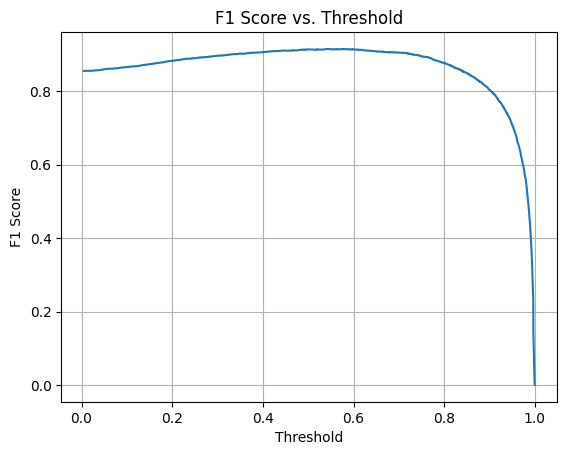

In [ ]:
probs = model.predict({
    "input_ids": x_test["input_ids"],
    "attention_mask": x_test["attention_mask"]
}).flatten()

y_true = y_test

precision, recall, thresholds = precision_recall_curve(y_true, probs)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")

plt.plot(thresholds, f1_scores[:-1])
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Threshold")
plt.grid(True)
plt.show()

147/147 ━━━━━━━━━━━━━━━━━━━━ 40s 271ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.67      0.72      1193
           1       0.89      0.94      0.91      3505

    accuracy                           0.87      4698
   macro avg       0.84      0.80      0.82      4698
weighted avg       0.86      0.87      0.87      4698



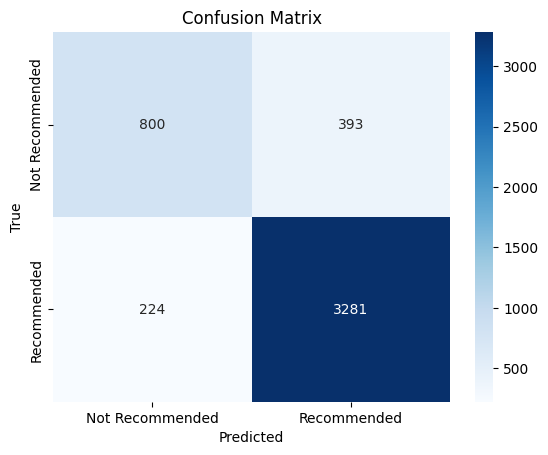

ROC-AUC: 0.9271084416586053


In [ ]:
y_pred_probs = model.predict(x_test)
y_pred = (y_pred_probs > 0.54).astype(int)

print("Classification Report:\n", classification_report(y_test, y_pred))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Recommended", "Recommended"],
            yticklabels=["Not Recommended", "Recommended"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("ROC-AUC:", roc_auc_score(y_test, y_pred_probs))

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8687
Precision: 0.8930
Recall (Sensitivity): 0.9361
F1 Score: 0.9141


In [ ]:
df['Review Date'] = pd.to_datetime(df['Review Date'], errors='coerce')

df['Predicted_Prob'] = model.predict({
    "input_ids": encodings["input_ids"],
    "attention_mask": encodings["attention_mask"]
}).flatten()

df['Predicted_Adoption'] = (df['Predicted_Prob'] > 0.54).astype(int)

734/734 ━━━━━━━━━━━━━━━━━━━━ 194s 264ms/step


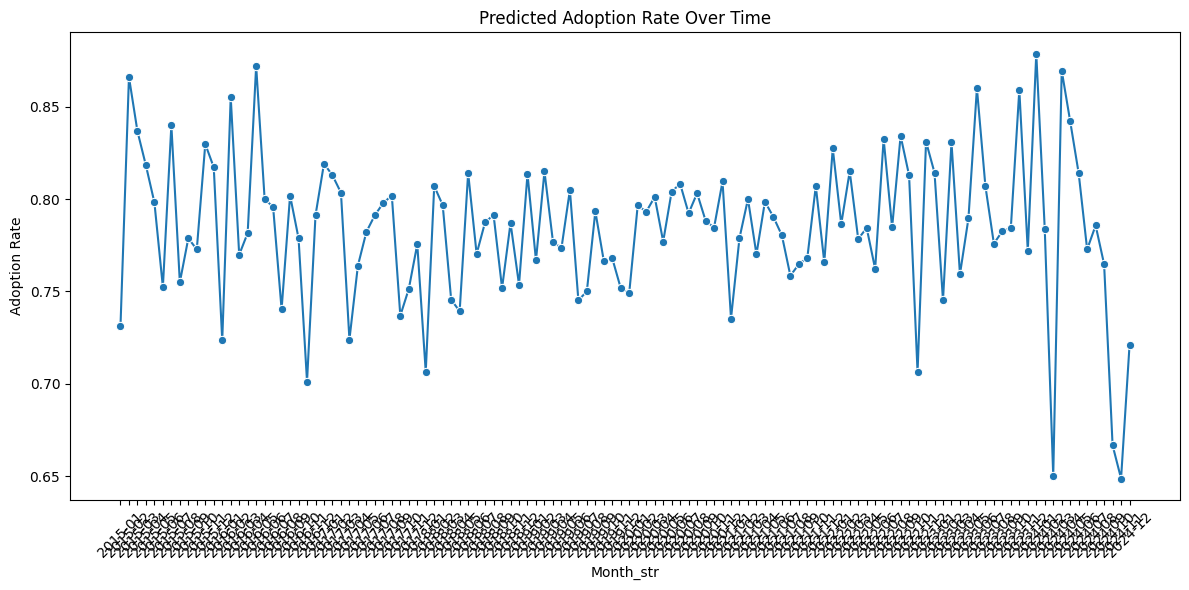

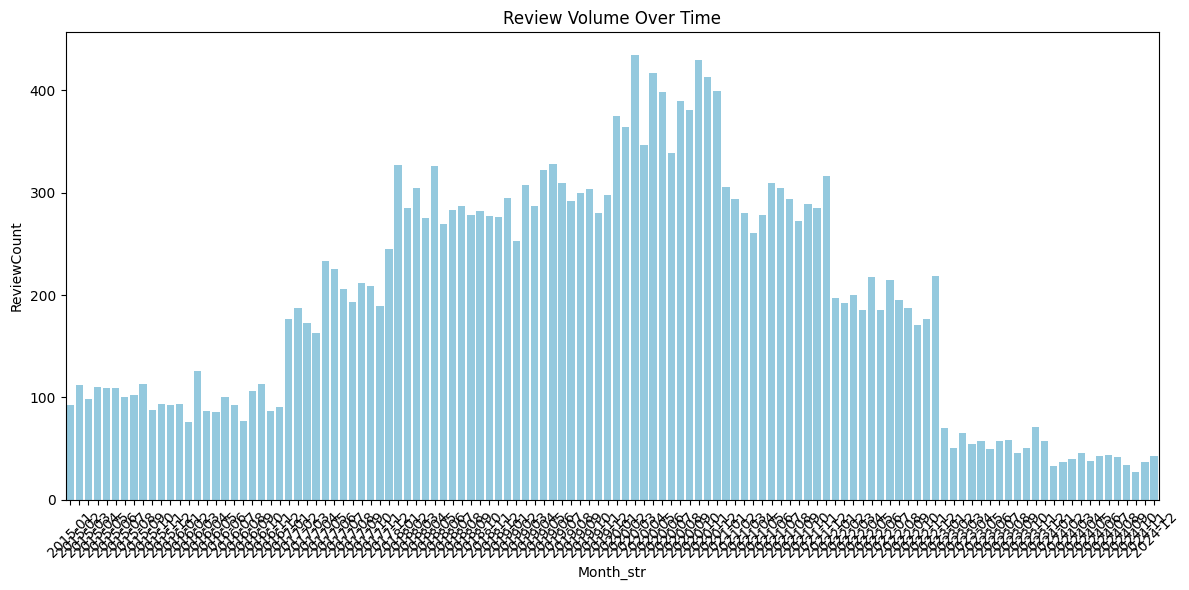

In [ ]:
df['Review Date'] = pd.to_datetime(df['Review Date'], errors='coerce')
df = df.dropna(subset=['Review Date'])

df['Month_str'] = df['Review Date'].dt.to_period('M').astype(str)

trend_df = df.groupby('Month_str').agg({
    'Predicted_Adoption': ['mean', 'count'],
    'Rating': 'mean'
}).reset_index()

trend_df.columns = ['Month_str', 'AdoptionRate', 'ReviewCount', 'AverageRating']

trend_df['Month_str'] = pd.to_datetime(trend_df['Month_str'])
trend_df = trend_df.sort_values('Month_str')
trend_df['Month_str'] = trend_df['Month_str'].dt.strftime('%Y-%m')

plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_df, x='Month_str', y='AdoptionRate', marker='o')
plt.title('Predicted Adoption Rate Over Time')
plt.xticks(rotation=45)
plt.ylabel('Adoption Rate')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=trend_df, x='Month_str', y='ReviewCount', color='skyblue')
plt.title('Review Volume Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

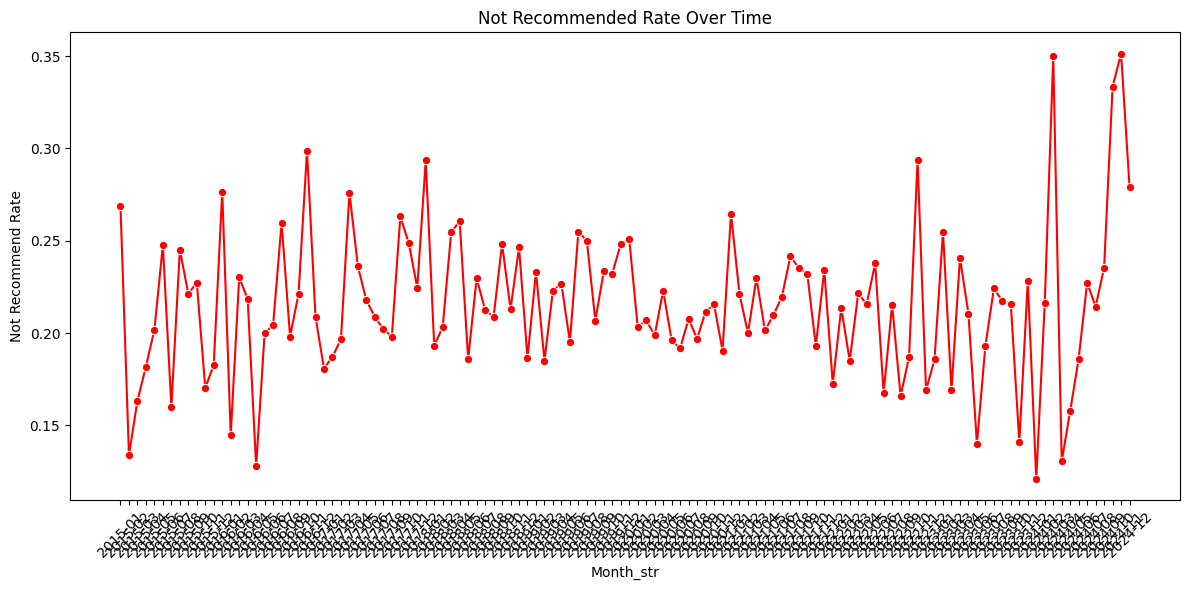

In [ ]:
df['Review Date'] = pd.to_datetime(df['Review Date'], errors='coerce')
df = df.dropna(subset=['Review Date'])
df['Month_str'] = df['Review Date'].dt.to_period('M').astype(str)

not_recommended_df = df[df['Predicted_Adoption'] == 0].groupby(
    'Month_str').size().reset_index(name='NotRecommendedCount')
total_reviews_df = df.groupby(
    'Month_str').size().reset_index(name='TotalReviews')

merged_df = pd.merge(not_recommended_df, total_reviews_df, on='Month_str')
merged_df['NotRecommendRate'] = merged_df[
    'NotRecommendedCount'] / merged_df['TotalReviews']

merged_df['Month_str'] = pd.to_datetime(merged_df['Month_str'])
merged_df = merged_df.sort_values('Month_str')
merged_df['Month_str'] = merged_df['Month_str'].dt.strftime('%Y-%m')

plt.figure(figsize=(12, 6))
sns.lineplot(data=merged_df, x='Month_str', y='NotRecommendRate',
             marker='o', color='red')
plt.title('Not Recommended Rate Over Time')
plt.xticks(rotation=45)
plt.ylabel('Not Recommend Rate')
plt.tight_layout()
plt.show()

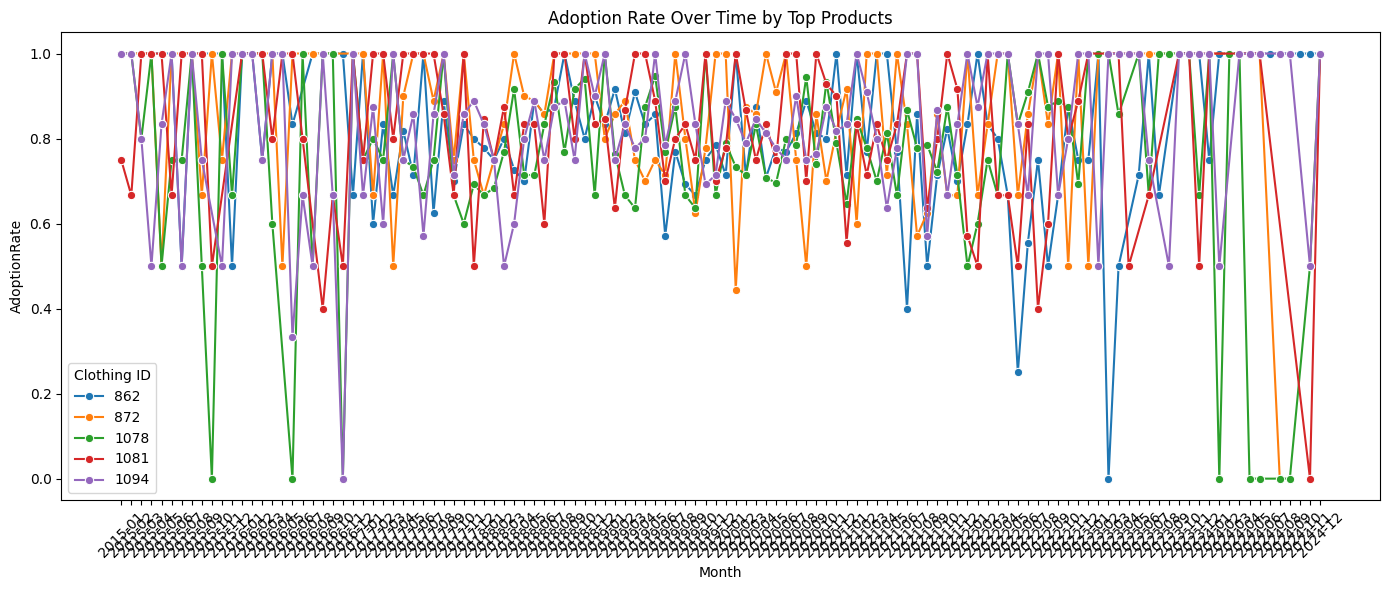

In [ ]:
df['Review Date'] = pd.to_datetime(df['Review Date'], errors='coerce')
df = df.dropna(subset=['Review Date'])

df['Month'] = df['Review Date'].dt.to_period('M').astype(str)

product_trend = df.groupby(['Clothing ID', 'Month']).agg({
    'Predicted_Adoption': 'mean',
    'Review Text': 'count'
}).reset_index().rename(columns={
    'Predicted_Adoption': 'AdoptionRate',
    'Review Text': 'ReviewCount'
})

product_trend['Month'] = pd.to_datetime(product_trend['Month'])
product_trend = product_trend.sort_values('Month')
product_trend['Month'] = product_trend['Month'].dt.strftime('%Y-%m')


top_products = product_trend.groupby(
    'Clothing ID')['ReviewCount'].sum().nlargest(5).index

product_trend_top = product_trend[
    product_trend['Clothing ID'].isin(top_products)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=product_trend_top, x='Month', y='AdoptionRate',
             hue='Clothing ID', marker='o', palette='tab10')
plt.title('Adoption Rate Over Time by Top Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

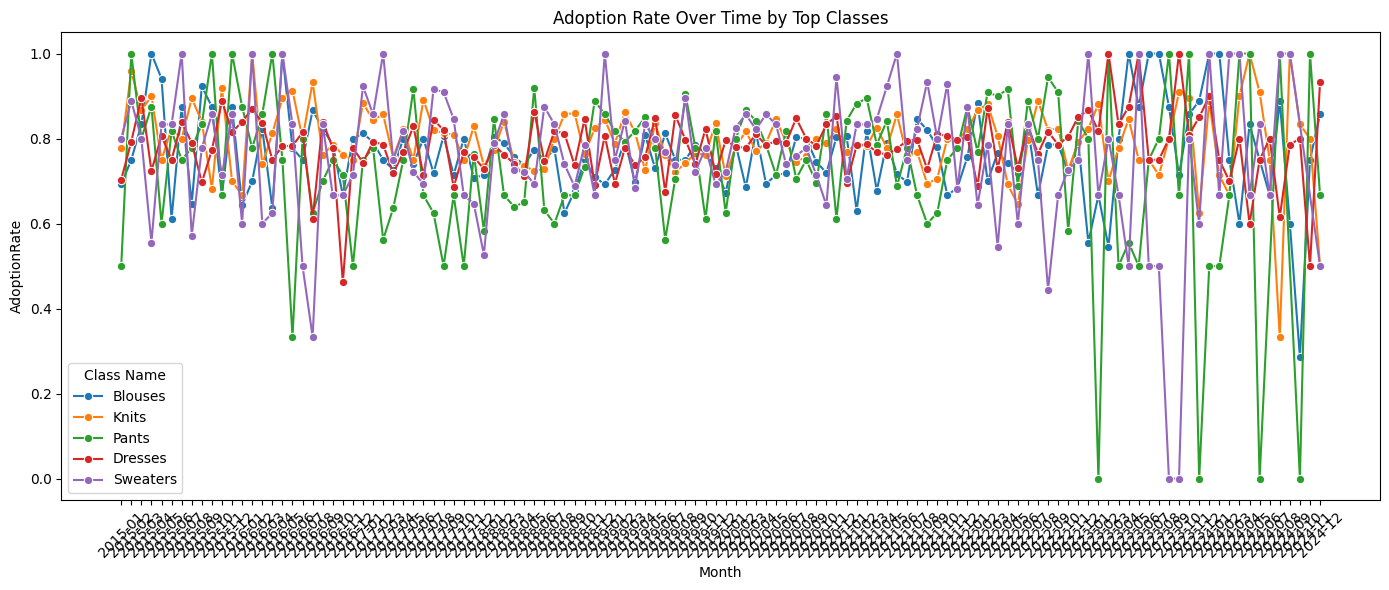

In [ ]:
class_trend = df.groupby(['Class Name', 'Month']).agg({
    'Predicted_Adoption': 'mean',
    'Review Text': 'count'
}).reset_index().rename(columns={
    'Predicted_Adoption': 'AdoptionRate',
    'Review Text': 'ReviewCount'
})

class_trend['Month'] = pd.to_datetime(class_trend['Month'])
class_trend = class_trend.sort_values('Month')
class_trend['Month'] = class_trend['Month'].dt.strftime('%Y-%m')

top_classes = class_trend.groupby(
    'Class Name')['ReviewCount'].sum().nlargest(5).index
class_trend_top = class_trend[class_trend['Class Name'].isin(top_classes)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=class_trend_top, x='Month', y='AdoptionRate',
             hue='Class Name', marker='o')
plt.title('Adoption Rate Over Time by Top Classes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-36-3abb6c93c36d>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_trend = df.groupby(['Age Range', 'Month']).agg({
<ipython-input-36-3abb6c93c36d>:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_ages = age_trend.groupby('Age Range')['ReviewCount'].sum().nlargest(5).index


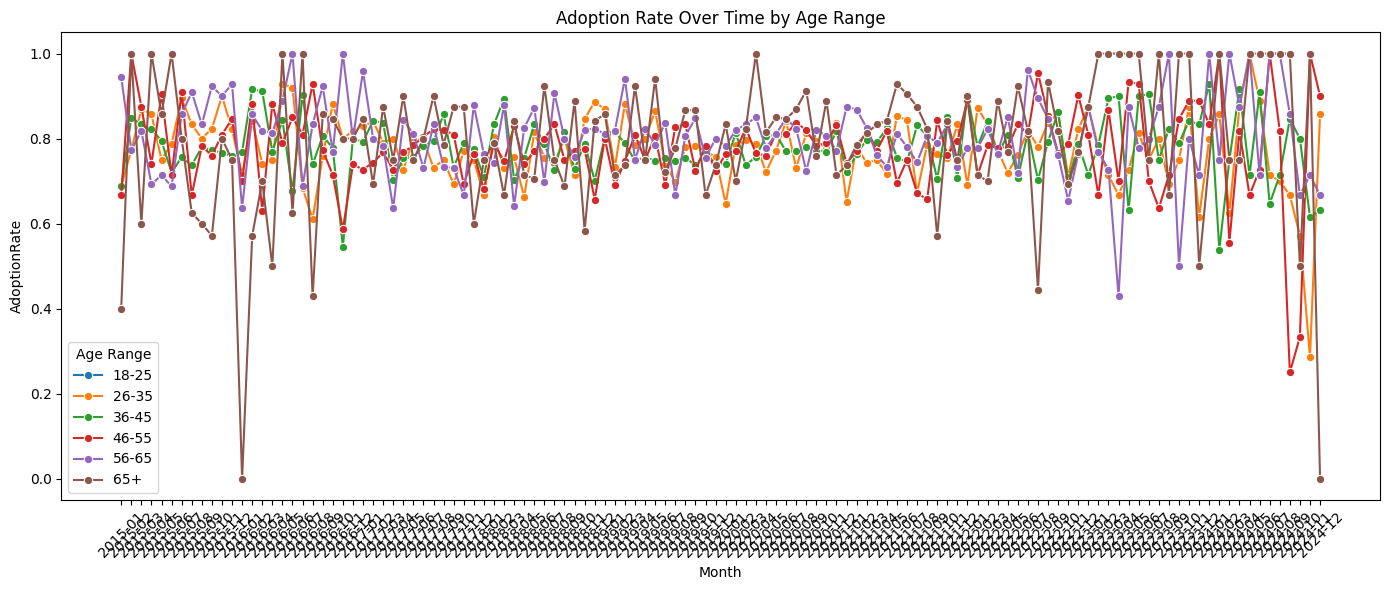

In [ ]:
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['Age Range'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

age_trend = df.groupby(['Age Range', 'Month']).agg({
    'Predicted_Adoption': 'mean',
    'Review Text': 'count'
}).reset_index().rename(columns={
    'Predicted_Adoption': 'AdoptionRate',
    'Review Text': 'ReviewCount'
})

age_trend['Month'] = pd.to_datetime(age_trend['Month'])
age_trend = age_trend.sort_values('Month')
age_trend['Month'] = age_trend['Month'].dt.strftime('%Y-%m')

top_ages = age_trend.groupby('Age Range')['ReviewCount'].sum().nlargest(5).index
age_trend_top = age_trend[age_trend['Age Range'].isin(top_ages)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=age_trend_top, x='Month', y='AdoptionRate',
             hue='Age Range', marker='o')
plt.title('Adoption Rate Over Time by Age Range')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
